# Sanghelios — Preprocesamiento atenciones
**Hospital General de Medellín**

Preprocesamiento del DataFrame de atenciones y creacion de serie temporal atenciones por dia.

| | |
|---|---|
| **Proyecto** | Sanghelios |
| **Autor** | Jose Miguel García Vélez |
| **Datos** | [atenciones.csv](https://github.com/Semillero-Inteligencia-Artificial-EAFIT/Sanghelios/blob/main/data/raw/atenciones.csv) — Atenciones HGM |
| **Período** | 2022 – 2025 |

---

# 0. Importación, carga de datos y estandarización de graficas

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
path = {"atenciones": r"..\data\raw\atenciones.csv"}

df_atenciones = pd.read_csv(path["atenciones"], low_memory=False)
print(f"'{path['atenciones']}' loaded successfully. Shape: {df_atenciones.shape}")

print("\nDimensiones de el DataFrame:")
print("Atenciones:", df_atenciones.shape)

'..\data\raw\atenciones.csv' loaded successfully. Shape: (221203, 12)

Dimensiones de el DataFrame:
Atenciones: (221203, 12)


In [3]:
# Estilo global para graficas y helpers
def set_plot_style():
    plt.style.use("seaborn-v0_8-whitegrid")
    sns.set_context("notebook", font_scale=1.05)
    sns.set_palette(["#2E86AB", "#1B4F72", "#C0392B", "#27AE60", "#F39C12"])


def boxplot_pro(series, title, xlabel):
    data = series.dropna()
    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor("#F7F9FB")
    ax.boxplot(
        data,
        vert=False,
        widths=0.5,
        patch_artist=True,
        boxprops={"facecolor": "#2E86AB", "alpha": 0.6, "edgecolor": "#1B4F72"},
        medianprops={"color": "#C0392B", "linewidth": 2},
        whiskerprops={"color": "#1B4F72", "linewidth": 1.5},
        capprops={"color": "#1B4F72", "linewidth": 1.5},
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "#F39C12",
            "markeredgecolor": "#B9770E",
            "alpha": 0.5,
        },
        showmeans=True,
        meanprops={
            "marker": "D",
            "markerfacecolor": "#27AE60",
            "markeredgecolor": "#1E8449",
        },
    )
    ax.set_title(title, pad=12, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_yticks([])

    q1, q2, q3 = data.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    ax.text(
        0.99,
        0.85,
        f"n={len(data):,}\nmediana={q2:.1f}\nIQR={iqr:.1f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.9,
            "edgecolor": "#D5D8DC",
        },
    )

    plt.tight_layout()
    plt.show()

# 1. Información inicial del DataFrame

In [4]:
def explorar_df(nombre, df):
    print(f"\n{nombre}  —  {df.shape[0]:,} filas × {df.shape[1]} columnas")

    info = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "nulos": df.isna().sum(),
            "% nulos": (df.isna().mean() * 100).round(1),
            **{f"ej {i+1}": df.iloc[i] for i in range(min(5, len(df)))},
        }
    )

    display(info)


df_atenciones = df_atenciones.copy()

In [5]:
explorar_df("Atenciones", df_atenciones)


Atenciones  —  221,203 filas × 12 columnas


,dtype,nulos,% nulos,ej 1,ej 2,ej 3,ej 4,ej 5
AÑO,int64,0,0.0,2022,2022,2022,2022,2022
Periodo de reporte,int64,0,0.0,1,1,1,1,1
Fecha atencion,object,0,0.0,02/01/2022,02/01/2022,02/01/2022,02/01/2022,02/01/2022
servicio,object,0,0.0,Ambulatorio,Ambulatorio,Ambulatorio,Ambulatorio,Hospitalizado
Sexo,object,5,0.0,M,M,M,M,M
Cod. Aseguradora,float64,4972,2.2,20002686.0,20000362.0,20000368.0,20000366.0,20000368.0
Aseguradora,object,4972,2.2,ALIANZA MEDELLIN ANTIOQUIA EPS SUBSIDIADO ISS ...,"AXA COLPATRIA SEGUROS SA, SOAT",SEGUROS LA PREVISORA,SEGUROS DEL ESTADO,SEGUROS LA PREVISORA
Poblacion,object,57998,26.2,20 DE JULI O,Barrio Cristobal LA AMERICA,Playon de Los Comuneros SANTA CRUZ,Aures No2 ROBLEDO,NaN
Departamento,object,436,0.2,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA,ANTIOQUIA
edad,int64,0,0.0,2,35,24,23,32


In [6]:
# Estandarizar nombres de columnas: eliminar espacios y convertir a minúsculas
df_atenciones.columns = (
    df_atenciones.columns.str.strip().str.lower().str.replace(" ", "_")
)
print("\nColumnas estandarizadas:")
print(df_atenciones.columns.tolist())


Columnas estandarizadas:
['año', 'periodo_de_reporte', 'fecha_atencion', 'servicio', 'sexo', 'cod._aseguradora', 'aseguradora', 'poblacion', 'departamento', 'edad', 'rango_de_edad', 'regimen']


# 2. Tipado

In [7]:
# Fecha de atencion: convertir a datetime
df_atenciones["fecha_atencion"] = pd.to_datetime(
    df_atenciones["fecha_atencion"].astype("string"), errors="coerce"
)

# Rango de fechas
fecha_min = df_atenciones["fecha_atencion"].min()
fecha_max = df_atenciones["fecha_atencion"].max()
print(f"\nRango de fechas en 'fecha_atencion': {fecha_min.date()} a {fecha_max.date()}")


Rango de fechas en 'fecha_atencion': 2022-01-02 a 2026-12-03


In [8]:
# Codigo asegurado: convertir a string (sin .0)
df_atenciones = df_atenciones.astype({"cod._aseguradora": "string"})
df_atenciones["cod._aseguradora"] = df_atenciones["cod._aseguradora"].str.replace(
    ".0", "", regex=False
)

# Ejemplo de valores unicos en 'Cod. Aseguradora'
print("\nEjemplo de valores unicos en 'Cod. Aseguradora':")
print(df_atenciones["cod._aseguradora"].unique()[:10])


Ejemplo de valores unicos en 'Cod. Aseguradora':
<StringArray>
['20002686', '20000362', '20000368', '20000366', '20000465', '20002569',
 '20003122', '20000348', '20002687', '20002818']
Length: 10, dtype: string


# 3. Estandarización de strings

In [9]:
# servicio → uppercase
df_atenciones["servicio"] = df_atenciones["servicio"].str.upper()

# Departamento → sin tildes, normalizado
df_atenciones["departamento"] = (
    df_atenciones["departamento"]
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
)

# rango de edad → unificar ≥65
df_atenciones["rango_de_edad"] = df_atenciones["rango_de_edad"].replace(
    {">= 65 AÑOS": "≥65 AÑOS"}
)

# regimen → OTRO / OTROS → OTRO
df_atenciones["regimen"] = df_atenciones["regimen"].replace(
    {"OTRO": "OTRO", "OTROS": "OTRO"}
)

# Sexo = 'I' → NaN
df_atenciones["sexo"] = df_atenciones["sexo"].replace({"I": np.nan})

# 4. Columna Poblacion

In [10]:
# Separar en barrio y comuna
import re


def separar_poblacion(valor):
    """
    Separa la columna Poblacion en (barrio, comuna) según el patrón detectado.

    Patrones:
      - 'barrio  COMUNA'        → (barrio, COMUNA)   [doble espacio como separador]
      - 'MUNICIPIO MUNICIPIO'   → (NaN, MUNICIPIO)   [repetición = sin barrio]
      - 'NombreSolo'            → (NombreSolo, NaN)  [solo barrio / ambiguo]
      - Triple estructura       → tomar primeras dos partes
      - NaN                     → (NaN, NaN)
    """
    if pd.isna(valor):
        return pd.NA, pd.NA

    # Normalizar 3+ espacios consecutivos a doble espacio
    valor = re.sub(r"   +", "  ", valor.strip())

    # ── Caso 1: tiene doble espacio → separar ─────────────────────────────
    partes = re.split(r"  ", valor)
    if len(partes) >= 2:
        barrio = partes[0].strip() or pd.NA
        comuna = partes[1].strip() or pd.NA
        return barrio, comuna

    # ── Caso 2: espacio simple → detectar patrón MUNICIPIO MUNICIPIO ──────
    nombre = valor.strip()
    tokens = nombre.split()
    mitad = len(tokens) // 2

    if len(tokens) >= 2 and len(tokens) % 2 == 0:
        primera = " ".join(tokens[:mitad]).upper()
        segunda = " ".join(tokens[mitad:]).upper()
        if primera == segunda:
            return pd.NA, primera  # municipio sin barrio

    # ── Caso 3: solo nombre → barrio ──────────────────────────────────────
    return nombre, pd.NA


# Aplicar al dataset
result = df_atenciones["poblacion"].apply(separar_poblacion)
df_atenciones["poblacion_barrio"] = result.apply(lambda x: x[0])
df_atenciones["poblacion_comuna"] = result.apply(lambda x: x[1])

# Corregir typo conocido en comuna
df_atenciones["poblacion_comuna"] = df_atenciones["poblacion_comuna"].replace(
    {"CASTILLLA": "CASTILLA"}
)

# Eliminar columna original
df_atenciones = df_atenciones.drop(columns=["poblacion"])

# ── Reporte ───────────────────────────────────────────────────────────────
print("Cobertura de poblacion_barrio:")
print(f"  No-nulo: {df_atenciones['poblacion_barrio'].notna().sum():,}")
print(
    f"  Nulo:    {df_atenciones['poblacion_barrio'].isna().sum():,}  "
    f"({df_atenciones['poblacion_barrio'].isna().mean()*100:.1f}%)"
)
print()
print("Cobertura de poblacion_comuna:")
print(f"  No-nulo: {df_atenciones['poblacion_comuna'].notna().sum():,}")
print(
    f"  Nulo:    {df_atenciones['poblacion_comuna'].isna().sum():,}  "
    f"({df_atenciones['poblacion_comuna'].isna().mean()*100:.1f}%)"
)
print()
print("Top 10 barrios:")
print(df_atenciones["poblacion_barrio"].value_counts().head(10))
print()
print("Top 10 comunas:")
print(df_atenciones["poblacion_comuna"].value_counts().head(10))

Cobertura de poblacion_barrio:
  No-nulo: 138,312
  Nulo:    82,891  (37.5%)

Cobertura de poblacion_comuna:
  No-nulo: 94,946
  Nulo:    126,257  (57.1%)

Top 10 barrios:
poblacion_barrio
BELLO            8651
Robledo          4492
Buenos Aires     3300
Villa Hermosa    2797
ITAGUI           2754
Manrique         2547
Popular          2443
Castilla         2166
Aranjuez         1989
Enciso           1467
Name: count, dtype: int64

Top 10 comunas:
poblacion_comuna
BELLO            11587
ROBLEDO           5136
BUENOS AIRES      4775
MANRIQUE          4362
ITAGUI            3917
POPULAR           2864
VILLA HERMOSA     2782
ARANJUEZ          2405
CASTILLA          1984
COPACABANA        1922
Name: count, dtype: int64


Documentación de nulos

Los **57,998 nulos (26.2%)** en `poblacion` son **estructurales**: corresponden a pacientes
atendidos en el HGM que residen fuera de Medellín (otros municipios o departamentos).
Su residencia ya queda capturada en `departamento`. Se conservan como `NaN` en ambas
columnas derivadas — **no se imputan**.

> La columna original `poblacion` se elimina tras la separación.

# 5. Outliers

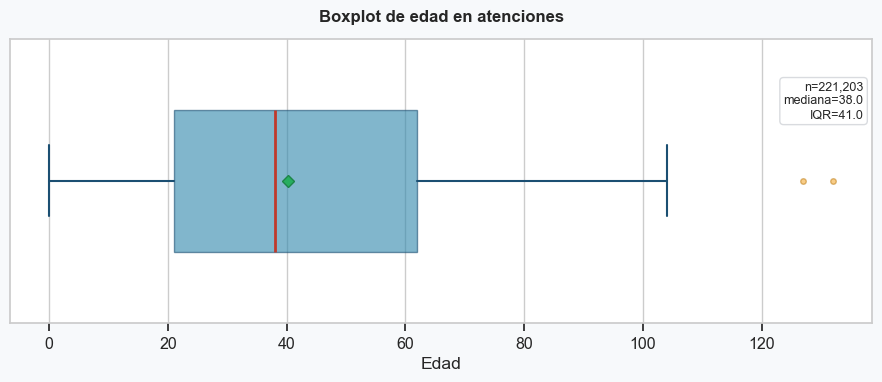

In [11]:
# Boxplot edad (estandarizado)
set_plot_style()
boxplot_pro(df_atenciones["edad"], title="Boxplot de edad en atenciones", xlabel="Edad")

In [12]:
# Ver edades mayores a 120 años
print("\nAtenciones con edad > 120 años:")
print(df_atenciones[df_atenciones["edad"] > 120][["edad", "fecha_atencion"]])

# La edad mas alta registrada en la historia es de 122 años, por lo que estos datos atipicos podrían ser errores de digitación o registros incorrectos. Procedemos a elimirlos.

df_atenciones = df_atenciones[df_atenciones["edad"] <= 120]

# Rango de edades
print("\nRango de edades en atenciones:")
print(f"Edad mínima: {df_atenciones['edad'].min()}")
print(f"Edad máxima: {df_atenciones['edad'].max()}")


Atenciones con edad > 120 años:
        edad fecha_atencion
201987   132            NaT
212636   127     2026-10-03

Rango de edades en atenciones:
Edad mínima: 0
Edad máxima: 104


# 7. Cortar rango fechas para serie de tiempo

In [13]:
# Definir fechas hasta 2025-06-27
fecha_limite = pd.to_datetime("2025-06-27")
df_2 = df_atenciones.loc[df_atenciones["fecha_atencion"] <= fecha_limite].copy()

# Rango de fechas en 'fecha_atencion' después de filtrar
fecha_min_2 = df_2["fecha_atencion"].min()
fecha_max_2 = df_2["fecha_atencion"].max()
print(
    f"\nRango de fechas en 'fecha_atencion' después de filtrar: {fecha_min_2.date()} a {fecha_max_2.date()}"
)


Rango de fechas en 'fecha_atencion' después de filtrar: 2022-01-02 a 2025-06-12


# 8. Atenciones por dia serie de timpo

In [14]:
# Numero de atenciones por dia
atenciones_por_dia = df_2.groupby("fecha_atencion").size()
print("\nNúmero de atenciones por día (primeros 10 días):")
print(atenciones_por_dia.head(3))

# Crear columna con el número de atenciones por día
df_2.loc[:, "atenciones_por_dia"] = df_2["fecha_atencion"].map(atenciones_por_dia)
print("\nEjemplo de filas con la nueva columna 'atenciones_por_dia':")
display(df_2[["fecha_atencion", "atenciones_por_dia"]].head(3))

# compararar atenciones_por_dia y la nueva columna 'atenciones_por_dia' para verificar que coinciden
comparacion = df_2["atenciones_por_dia"] == df_2["fecha_atencion"].map(
    atenciones_por_dia
)
print(f"\n¿Las columnas 'atenciones_por_dia' y el mapeo coinciden? {comparacion.all()}")


Número de atenciones por día (primeros 10 días):
fecha_atencion
2022-01-02    223
2022-01-03    242
2022-01-04    264
dtype: int64

Ejemplo de filas con la nueva columna 'atenciones_por_dia':


,fecha_atencion,atenciones_por_dia
0,2022-02-01,44
1,2022-02-01,44
2,2022-02-01,44



¿Las columnas 'atenciones_por_dia' y el mapeo coinciden? True


In [15]:
# Convertir tabla en un DataFrame
atenciones_por_dia = (
    df_2.groupby("fecha_atencion").size().reset_index(name="atenciones_por_dia")
)
display(atenciones_por_dia.head(10))

# Cambiar nombre y exportar a csv
atenciones_por_dia.to_csv("../data/processed/df_atenciones_time_series.csv", index=True)

,fecha_atencion,atenciones_por_dia
0,2022-01-02,223
1,2022-01-03,242
2,2022-01-04,264
3,2022-01-05,70
4,2022-01-06,573
5,2022-01-07,401
6,2022-01-08,413
7,2022-01-09,349
8,2022-01-10,45
9,2022-01-11,306


# 9. Exportar datos para EDA

In [16]:
atenciones_processed = df_atenciones.copy()
atenciones_processed.to_csv(
    "../data/processed/df_atenciones_processed.csv", index=False
)